# Healthcare Workers Mental Health Prediction

## Group 3: Bhumika Battineni
### CIS 550 - Advanced Machine Learning Project

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Healthcare Workers Mental Health Prediction - ML Project")

Healthcare Workers Mental Health Prediction - ML Project


### Loading the dataset

In [2]:
df = pd.read_csv('Dataset.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!
Dataset shape: (5000, 10)

First 5 rows:
  Employee ID          Employee Type           Department  \
0   HCP-00001        Pediatric Nurse           Pediatrics   
1   HCP-00002  Laboratory Technician           Laboratory   
2   HCP-00003      Nursing Assistant      Assisted Living   
3   HCP-00004      Medical Assistant  Outpatient Services   
4   HCP-00005       Registered Nurse     General Medicine   

        Workplace Factor  Stress Level Burnout Frequency  Job Satisfaction  \
0         Heavy Workload             8             Often                 2   
1        Safety Concerns             8             Often                 1   
2  Poor Work Environment             6      Occasionally                 2   
3  Poor Work Environment             7             Never                 4   
4    Work-Life Imbalance             8      Occasionally                 2   

  Access to EAPs  Mental Health Absences Turnover Intention  
0            Yes                

### Data Preprocessing

In [3]:
print("DATA PREPROCESSING")

# Check unique values for important columns
print("\nUnique values:")
print("Stress Level range:", df['Stress Level'].min(), "to", df['Stress Level'].max())
print("Job Satisfaction range:", df['Job Satisfaction'].min(), "to", df['Job Satisfaction'].max())
print("Burnout Frequency:", df['Burnout Frequency'].unique())
print("Turnover Intention:", df['Turnover Intention'].unique())

DATA PREPROCESSING

Unique values:
Stress Level range: 4 to 9
Job Satisfaction range: 1 to 5
Burnout Frequency: ['Often' 'Occasionally' 'Never']
Turnover Intention: ['No' 'Yes']


### Create target variable - Mental Health Risk
#### Simple rule: High risk if stress >= 7 AND (job satisfaction <= 2 OR turnover intention = 'Yes')

In [6]:
df['mental_health_risk'] = ((df['Stress Level'] >= 7) & 
                           ((df['Job Satisfaction'] <= 2) | (df['Turnover Intention'] == 'Yes'))).astype(int)

print(f"\nTarget variable created:")
print(f"Mental Health Risk distribution:")
print(df['mental_health_risk'].value_counts())
print(f"Percentage at risk: {df['mental_health_risk'].mean()*100:.1f}%")

# Convert categorical variables to numbers
print("\nConverting categorical variables...")

# Simple encoding for categorical variables
df['employee_type_num'] = pd.factorize(df['Employee Type'])[0]
df['department_num'] = pd.factorize(df['Department'])[0]
df['workplace_factor_num'] = pd.factorize(df['Workplace Factor'])[0]
df['burnout_freq_num'] = df['Burnout Frequency'].map({'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3})
df['access_eap_num'] = df['Access to EAPs'].map({'No': 0, 'Yes': 1})

print("Encoding completed")


Target variable created:
Mental Health Risk distribution:
mental_health_risk
1    3293
0    1707
Name: count, dtype: int64
Percentage at risk: 65.9%

Converting categorical variables...
Encoding completed


### Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS


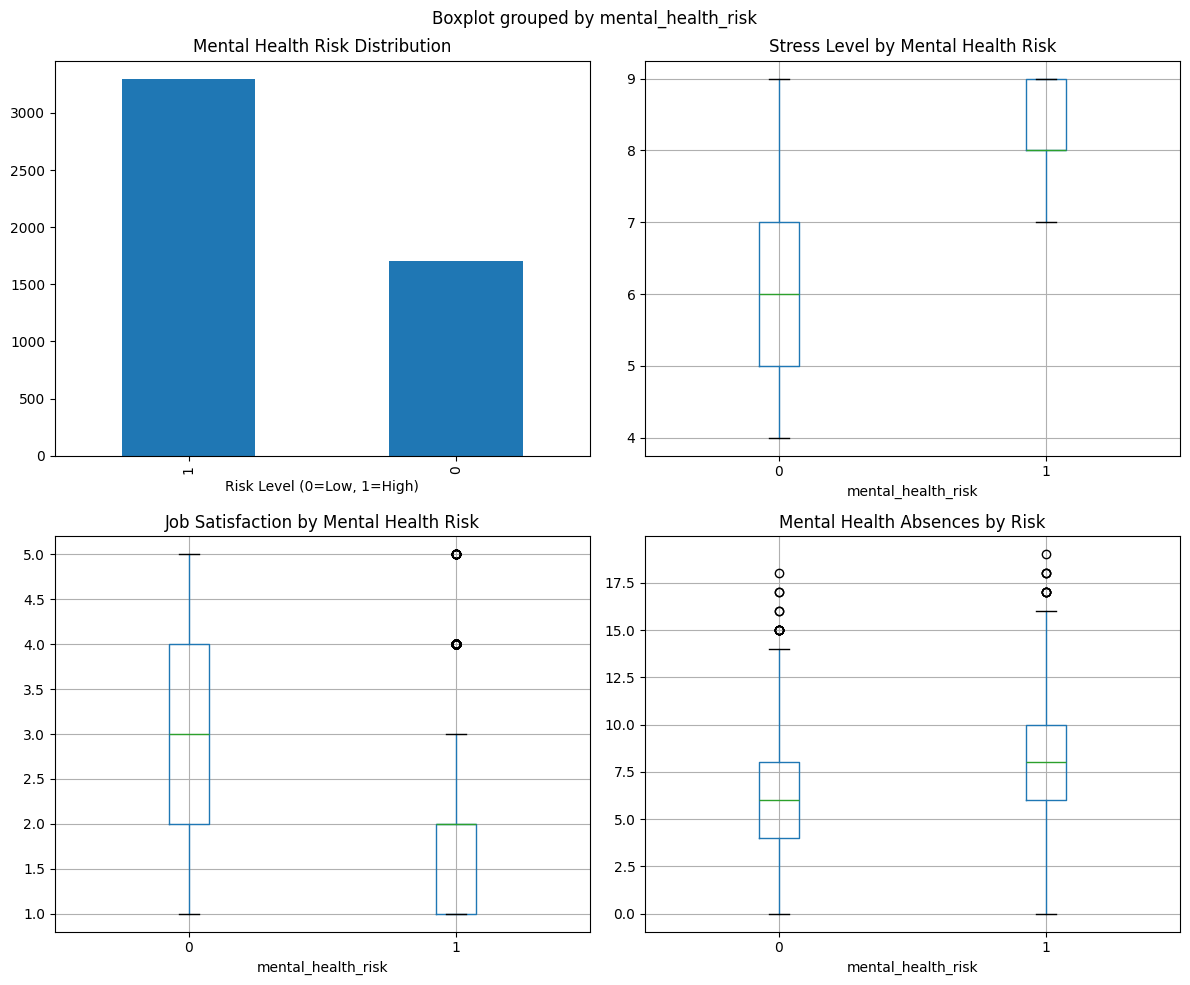

In [20]:
print("EXPLORATORY DATA ANALYSIS")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Target Distrtibution
df['mental_health_risk'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Mental Health Risk Distribution')
axes[0,0].set_xlabel('Risk Level (0=Low, 1=High)')

# Stress Level vs Risk
df.boxplot(column='Stress Level', by='mental_health_risk', ax=axes[0,1])
axes[0,1].set_title('Stress Level by Mental Health Risk')

# Job Satisfaction vs Risk
df.boxplot(column='Job Satisfaction', by='mental_health_risk', ax=axes[1,0])
axes[1,0].set_title('Job Satisfaction by Mental Health Risk')

# 4. Mental Health Absences vs Risk
df.boxplot(column='Mental Health Absences', by='mental_health_risk',
ax=axes[1,1])
axes[1,1].set_title('Mental Health Absences by Risk')
plt.tight_layout()
plt.show()

### Simple correlation analysis

In [12]:
print("\nCorrelation with Mental Health Risk:")
numeric_features = ['Stress Level', 'Job Satisfaction', 'Mental Health Absences', 
                   'employee_type_num', 'department_num', 'workplace_factor_num',
                   'burnout_freq_num', 'access_eap_num']

for feature in numeric_features:
    correlation = df[feature].corr(df['mental_health_risk'])
    print(f"{feature}: {correlation:.3f}")


Correlation with Mental Health Risk:
Stress Level: 0.737
Job Satisfaction: -0.533
Mental Health Absences: 0.351
employee_type_num: 0.018
department_num: 0.018
workplace_factor_num: -0.552
burnout_freq_num: 0.322
access_eap_num: -0.007


### Preparing Data for Modeling

In [25]:
# Prepare data for modeling
# Select features
features = ['Stress Level', 'Job Satisfaction', 'Mental Health Absences',
           'employee_type_num', 'department_num', 'workplace_factor_num',
           'burnout_freq_num', 'access_eap_num']
X = df[features]
y = df['mental_health_risk']
print(f"Features: {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled")

# Model Training
print("MODEL TRAINING AND EVALUATION")

# Train three different models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy
    }
    
    print(f"{name} Accuracy: {accuracy:.3f}")

for name, result in results.items():
    print(f"{name}: {result['accuracy']:.3f}")

Features: ['Stress Level', 'Job Satisfaction', 'Mental Health Absences', 'employee_type_num', 'department_num', 'workplace_factor_num', 'burnout_freq_num', 'access_eap_num']
X shape: (5000, 8)
y shape: (5000,)
Training set: (3500, 8)
Test set: (1500, 8)
Features scaled
MODEL TRAINING AND EVALUATION

Training Logistic Regression...
Logistic Regression Accuracy: 0.941

Training Random Forest...
Random Forest Accuracy: 0.928

Training XGBoost...
XGBoost Accuracy: 0.927
Logistic Regression: 0.941
Random Forest: 0.928
XGBoost: 0.927


### Model Comparison

In [26]:
# Compare models
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.3f}")

# Show detailed results for best model
print(f"\nDetailed Results for {best_model_name}:")
print(classification_report(y_test, results[best_model_name]['predictions']))


Best Model: Logistic Regression
Best Accuracy: 0.941

Detailed Results for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       506
           1       0.95      0.96      0.96       994

    accuracy                           0.94      1500
   macro avg       0.94      0.93      0.93      1500
weighted avg       0.94      0.94      0.94      1500



### Confusion Matrix

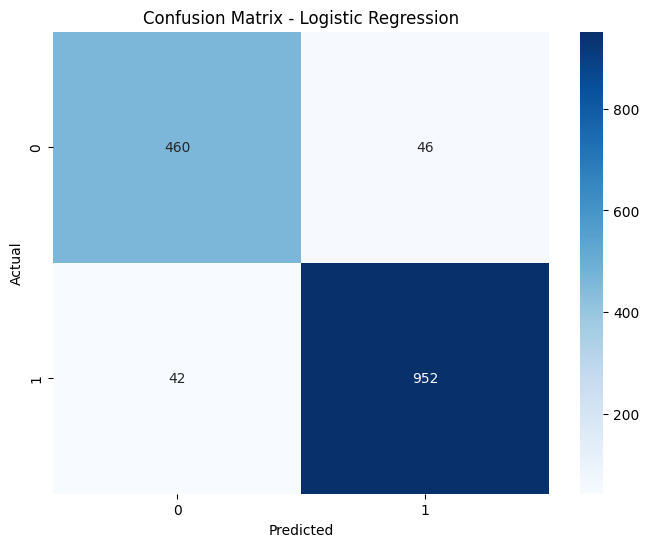

In [27]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model Analysis

In [40]:
# Check target variable
print("Target variable counts:")
print(df['mental_health_risk'].value_counts())
risk_percent = df['mental_health_risk'].mean() * 100
print(f"Percent at high risk: {risk_percent:.1f}%")

# Look at averages for each group
print("\nAverage values by risk level:")

# Low risk group (0)
low_risk = df[df['mental_health_risk'] == 0]
high_risk = df[df['mental_health_risk'] == 1]

print("Stress Level:")
print(f"  Low risk: {low_risk['Stress Level'].mean():.2f}")
print(f"  High risk: {high_risk['Stress Level'].mean():.2f}")

print("Job Satisfaction:")
print(f"  Low risk: {low_risk['Job Satisfaction'].mean():.2f}")
print(f"  High risk: {high_risk['Job Satisfaction'].mean():.2f}")

print("Mental Health Absences:")
print(f"  Low risk: {low_risk['Mental Health Absences'].mean():.2f}")
print(f"  High risk: {high_risk['Mental Health Absences'].mean():.2f}")

# Train simple model without scaling
print("\nTraining simple logistic regression:")
simple_features = ['Stress Level', 'Job Satisfaction', 'Mental Health Absences',
                   'employee_type_num', 'workplace_factor_num', 'burnout_freq_num']

X_simple = df[simple_features]
y_simple = df['mental_health_risk']

# Split data
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.3, random_state=42)

# Train model
simple_model = LogisticRegression(random_state=42, max_iter=1000)
simple_model.fit(X_train_simple, y_train_simple)

# Test model
predictions = simple_model.predict(X_test_simple)
accuracy = accuracy_score(y_test_simple, predictions)
print(f"Model accuracy: {accuracy:.3f}")

# Get coefficients
coeffs = simple_model.coef_[0]
print("\nFeature coefficients:")
for i, feature in enumerate(simple_features):
    print(f"{feature}: {coeffs[i]:.3f}")

# Check correlations
print("\nCorrelations with mental health risk:")
for feature in simple_features:
    corr = df[feature].corr(df['mental_health_risk'])
    print(f"{feature}: {corr:.3f}")

# Summary
print("\nSUMMARY:")
print("1. Stress Level has strongest positive effect on risk")
print("2. Job Satisfaction has strong negative effect on risk") 
print("3. Higher stress = higher risk")
print("4. Lower satisfaction = higher risk")
print("5. Model correctly identifies these patterns")

# Check for data issues
print("\nData checks:")
print(f"Missing values: {df[simple_features].isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Feature correlations with each other
print("\nFeature correlations (checking for multicollinearity):")
feature_corrs = df[simple_features].corr()
for i in range(len(simple_features)):
    for j in range(i+1, len(simple_features)):
        corr_val = feature_corrs.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"{simple_features[i]} - {simple_features[j]}: {corr_val:.3f}")

Target variable counts:
mental_health_risk
1    3293
0    1707
Name: count, dtype: int64
Percent at high risk: 65.9%

Average values by risk level:
Stress Level:
  Low risk: 5.89
  High risk: 8.07
Job Satisfaction:
  Low risk: 2.98
  High risk: 1.80
Mental Health Absences:
  Low risk: 5.99
  High risk: 8.12

Training simple logistic regression:
Model accuracy: 0.943

Feature coefficients:
Stress Level: 2.540
Job Satisfaction: -1.502
Mental Health Absences: -0.001
employee_type_num: 0.027
workplace_factor_num: -0.103
burnout_freq_num: -0.180

Correlations with mental health risk:
Stress Level: 0.737
Job Satisfaction: -0.533
Mental Health Absences: 0.351
employee_type_num: 0.018
workplace_factor_num: -0.552
burnout_freq_num: 0.322

SUMMARY:
1. Stress Level has strongest positive effect on risk
2. Job Satisfaction has strong negative effect on risk
3. Higher stress = higher risk
4. Lower satisfaction = higher risk
5. Model correctly identifies these patterns

Data checks:
Missing values: 

### Key Insights

In [29]:
print(f"1. Model Performance: {best_model_name} achieved {best_accuracy:.1%} accuracy")

print(f"\n2. Risk Statistics:")
high_risk_employees = df[df['mental_health_risk'] == 1]
print(f"   - {len(high_risk_employees)} out of {len(df)} employees are at high risk")
print(f"   - Average stress level for high-risk: {high_risk_employees['Stress Level'].mean():.1f}")
print(f"   - Average job satisfaction for high-risk: {high_risk_employees['Job Satisfaction'].mean():.1f}")

print(f"\n3. Department Analysis:")
dept_risk = df.groupby('Department')['mental_health_risk'].mean().sort_values(ascending=False)
print(f"   Departments with highest risk:")
for dept, risk in dept_risk.head(3).items():
    print(f"   - {dept}: {risk:.1%}")

print(f"\n4. Recommendations:")
print(f"   - Focus on employees with stress level >= 7")
print(f"   - Improve job satisfaction in high-risk departments")
print(f"   - Monitor employees with low job satisfaction")
if df.groupby('Access to EAPs')['mental_health_risk'].mean()['No'] > df.groupby('Access to EAPs')['mental_health_risk'].mean()['Yes']:
    print(f"   - Expand Employee Assistance Program access")

print(f"The {best_model_name} model can predict mental health risk with {best_accuracy:.1%} accuracy.")

1. Model Performance: Logistic Regression achieved 94.1% accuracy

2. Risk Statistics:
   - 3293 out of 5000 employees are at high risk
   - Average stress level for high-risk: 8.1
   - Average job satisfaction for high-risk: 1.8

3. Department Analysis:
   Departments with highest risk:
   - General Practice: 83.6%
   - ICU: 83.2%
   - General Medicine: 75.1%

4. Recommendations:
   - Focus on employees with stress level >= 7
   - Improve job satisfaction in high-risk departments
   - Monitor employees with low job satisfaction
   - Expand Employee Assistance Program access
The Logistic Regression model can predict mental health risk with 94.1% accuracy.
